# Homework assignment 5

**Deadline:** Sunday, 10 May 2025
<br><br>
**Student names:**: Williamina Fleming & Caterina Scarpellini ← **PLEASE REPLACE**
<br>
**Total hours spend:** ... h
<br><br>
**Important Remarks:**
<br>
* **Submitting the homework is a compulsory course component.** 
* Making mistakes or not always being able to completely solve an exercise is fine. The goal is to let you interactively explore the concepts from the lecture and identify common problems/misconceptions. If you could not solve/finish a task, please discuss why and what you tried using markdown cells.
* If you should have any questions please don't hesitate to ask them. This especially includes any questions on (astro)physical aspects of the exercises. You can use the discussions section in our Toledo Ultra course, or send emails with your question(s) directly to the TAs. Please do not give away your solution to problems to other student groups when using the discussions.
* Document what you are doing in markdown cells. Adding formulas is a good way to make your implementations in code easier to understand.
* Plots have to follow scientific standards. This includes the requirement of axis labels including measurement units if applicable!
* Indicate how much time you spend in total on this assignment.

**Submission Process:**
<br>
* Groups only need to submit a single notebook, there is no need for individual submissions.
* Rename the notebook as `HomeworkAssignment5_FirstnameLastname1_FirstnameLastname2.ipynb` where you insert your names in the filename.
* Send your notebook to both TAs (Dario Fritzewski: dario.fritzewski@kuleuven.be; Reinhold Willcox: reinhold.willcox@kuleuven.be) using the subject line "**Data Analysis Homework Submission 5**". You can make your notebook file smaller by deleting the outputs before submitting. If the notebook should still be too large for an email, please use [WeTransfer](https://wetransfer.com/).

# Imports

In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
from tinygp import kernels, GaussianProcess
import jaxopt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS



%matplotlib inline
from matplotlib import pyplot as plt
from IPython.display import Image

# Feel free to change these defaults
plt.rc('font',   size=16)          # controls default text sizes
plt.rc('axes',   titlesize=18)     # fontsize of the axes title
plt.rc('axes',   labelsize=18)     # fontsize of the x and y labels
plt.rc('xtick',  labelsize=18)     # fontsize of the tick labels
plt.rc('ytick',  labelsize=18)     # fontsize of the tick labels
plt.rc('legend', fontsize=18)      # legend fontsize
plt.rc('figure', titlesize=18)     # fontsize of the figure title
plt.rc('figure', dpi=75)           # Changed to 100 for some version >3.5.2

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


# Contents

1. [The Space Shuttle Challenger disaster](#Task-1:-The-Space-Shuttle-Challenger-disaster)
2. [Locating a radioactive source](#Task-2:-Locating-a-radioactive-source)
3. [The return of NGC 4472](#Task-3:-The-return-of-NGC-4472)

For the credits of the images, see [the homework page](https://github.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/blob/main/Images/credits.txt) of this course on GitHub.

---

## Task 1: The Space Shuttle Challenger disaster

On January 28, 1986, a disaster happened when the Space Shuttle *Challenger* exploded shortly after launch, killing all 7 crew members. The investigations afterwards showed that an O-ring, i.e. a ring-shaped piece of rubber used to seal two segments of the booster rocket, failed. This allowed highly flammable fuel to leak. The leaked fuel quickly ignited and destroyed the spaceship.

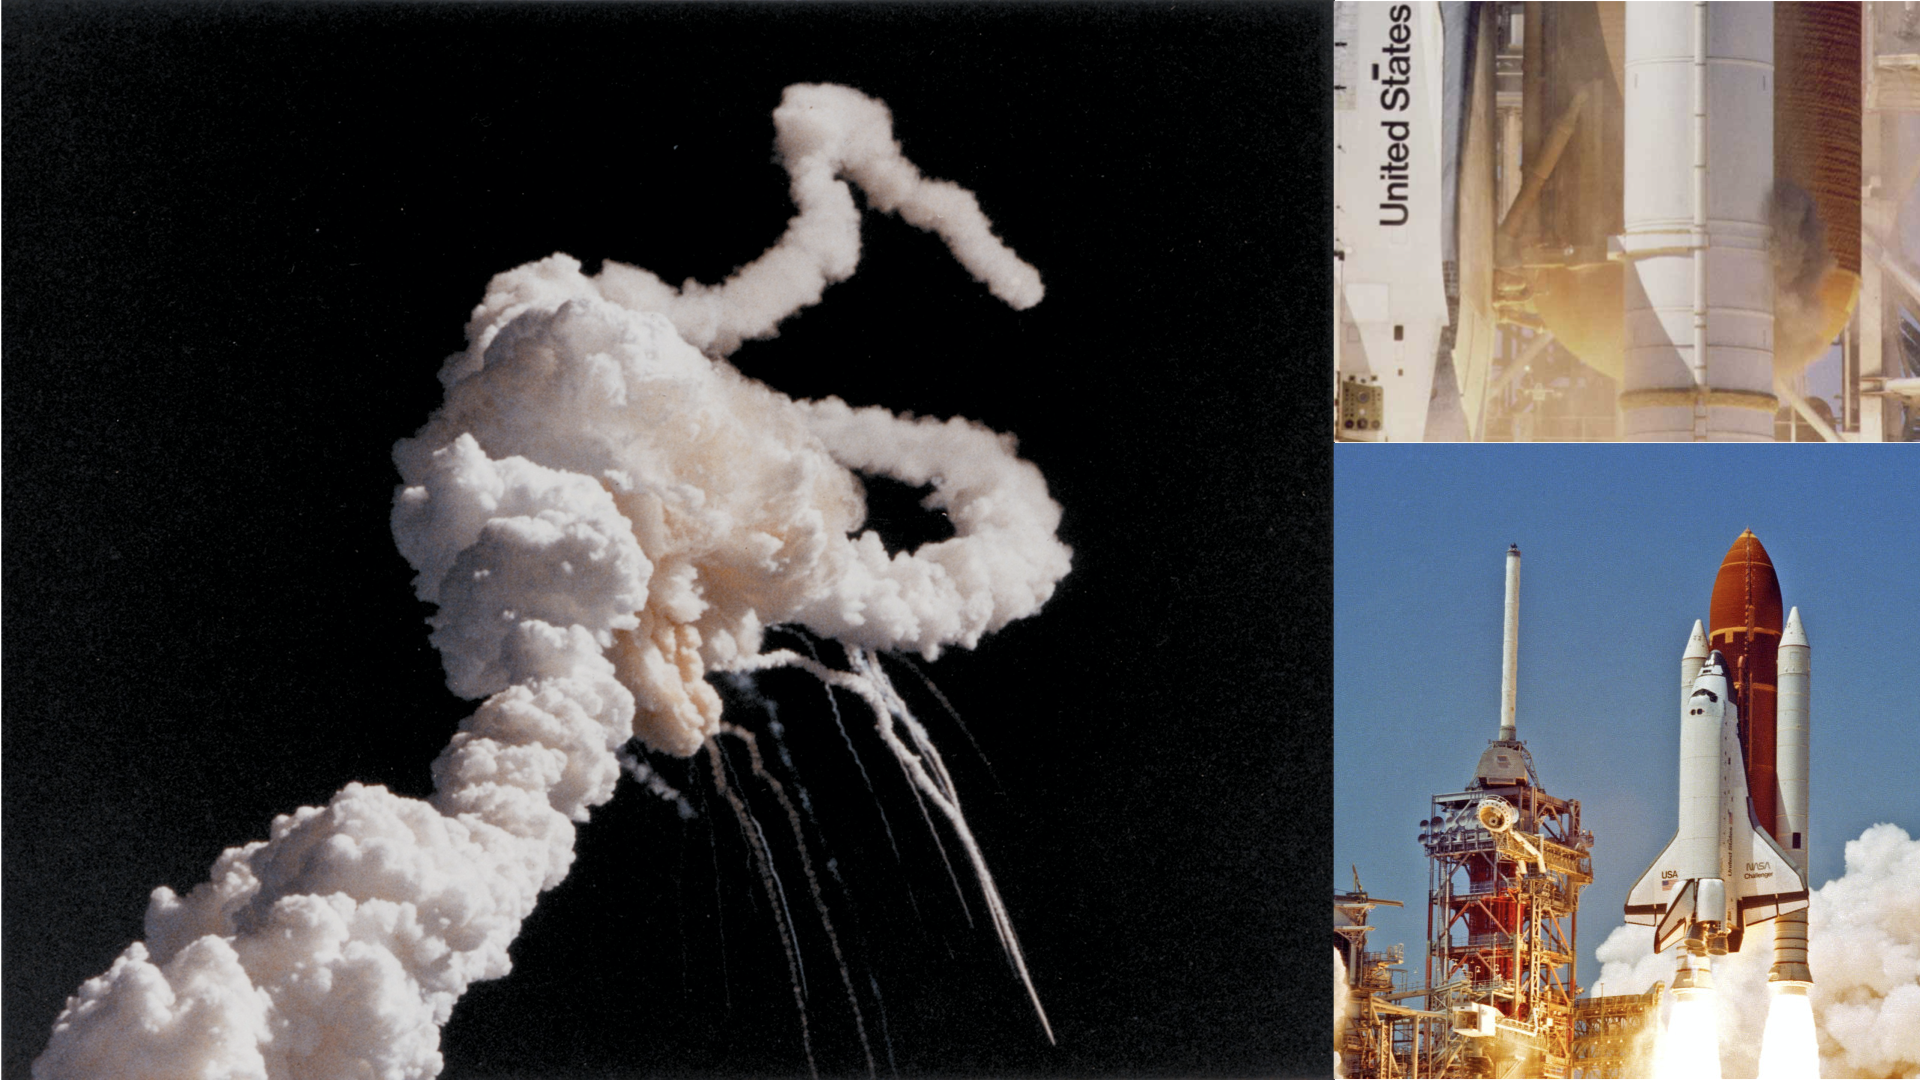

In [2]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/Challenger.png"
Image(url)

It is unclear how exactly the crew members died, because it is unknown whether the cockpit remained pressurized. The investigation did establish, however, that some electrical switches were moved manually *after* the crew cabin broke off the rest of the shuttle. If some crew member were alive during the free fall of the crew cabin, they were surely killed upon impact into the ocean at a velocity of more than 330 km/h.

The two solid rocket boosters were constructed of different sections. Some of the sections were sealed with rubber O-rings. These rings were qualified to work properly in a temperature of at least 14 °C. Unfortunately, that morning of Jan 28 was a very cold one, with temperatures close or below freezing point. As a result, the O-rings did not properly seal, and fuel leaked out.

In this exercise, you will investigate a dataset with data of O-ring failures known *prior* to the fatal Challenger launch.

In [3]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/OringFailures.csv"
data = pd.read_csv(url, comment='#')
data.head()

,T_Fahr,T_Celsius,failure
0,66,18.8,0
1,70,21.1,1
2,69,20.5,0
3,68,20.0,0
4,67,19.4,0


The columns are the following:
* **T_Fahr**:  ignore
* **T_Celsius**: temperature expressed in °C.
* **failure**: 1 if the O-ring failed, 0 if it didn't fail.

Your tasks are the following:

* Analyze this dataset using a Bayesian logistic regression with either PyMC, or UltraNest. Set up a model that estimates the posterior probability that an O-ring fails given the temperature $T$.
* Visualize the dataset together with the mean model. Visualize the joint and marginal distributions of your model parameters. 
* In the same plot, use posterior predictive sampling to visualize a 95% prediction interval of your model.  
* The temperature of that cold January morning was around 0 °C. This temperature is outside the range of the data, so it's in principle dangerous to extrapolate with your model. Nevertheless, derive the distribution of the probability that the O-ring fails at this temperature.
* Experiment with at least two different priors for each of the model parameters, and investigate how sensitive your posterior is to the prior choice.

---

## Task 2: Locating a radioactive source

The following problem is a 2-dimensional problem, everything occurs in the xy-plane. A tiny radioactive source is located on the y-axis at coordinates $(x,y)=(0,d)$ with $d$ the unknown distance in cm to the x-axis. The source is radiating gamma photons isotropically. On the x-axis a detector is placed, that extends from $x=-5$ cm to $x=5$ cm. When a photon hits the detector the x-position where it hits is registered. The figure below illustrates the configuration. Only the photons emitted with an angle between $-\theta_{\rm max}$ and $+\theta_{\rm max}$ are able to hit the detector. All other photons remain undetected.

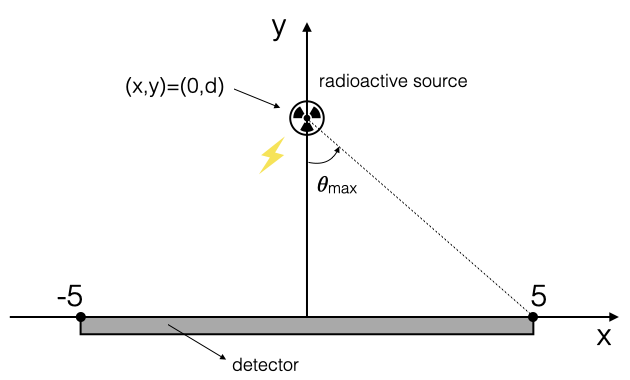

In [4]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/Fig_radioactive.png" 
Image(url, width=800)

The probability $P(k)$ that the source radiates $k$ photons in a time span $t$ (expressed in seconds) is given by the Poisson distribution:

$$ P(k) = \frac{(\lambda t)^k e^{-\lambda t}}{k!} $$

where $\lambda$ is the mean number of photons radiated **per second**. The probability $P(\Delta t)$ of the time span $\Delta t$ between two consecutive gamma photon emissions is given by the exponential distribution:

$$ P(\Delta t) = \lambda\,e^{-\lambda \, \Delta t} $$

In [5]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/data_radioactive.csv"
data = pd.read_csv(url)
data.head()

,t,x
0,0.070629,3.053372
1,0.387175,4.344606
2,1.176410,-4.840420
3,1.344172,3.796820
4,1.599441,-0.669742


In this data file the two columns are the following:
- **t**: the time point when the photon hits the detector [s]
- **x**: the x-coordinate where the photon hits the detector [cm]

Note that for this task the small time difference between emitting the photon and hitting the detector is not relevant.

Your tasks are the following:

- Choose a reasonable prior for the angle $\theta$ of the direction in which a photon that hits the detector was emitted.
- Apply the change-of-variables technique to analytically derive the likelihood $P(x)$ of a photon to hit the detector at position $x$. This likelihood will depend on the distance $d$ (or, equivalently and perhaps more conveniently, on the maximum hit angle $\theta_{\rm max}$).
- Use either PyMC or UltraNest with a custom likelihood to derive and visualize the posterior distribution of the distance $d$ of the radioactive source. Choose reasonable priors where required.
- Given this posterior distribution, compute a 95% credible interval for the distance $d$.

As mentioned before: if you get stuck, don't hesitate to ask for help: tell what you already tried but didn't work, and we'll help you further.

Since all angles are equally likely, a uniform prior on $\theta$ is reasonable. so $P(\theta) = \frac{1}{2\theta_{max}}$.
Since $tan(\theta) = x/d$, we can do a change of variable such that the likelihood $P(x) = \frac{d}{2\theta_{max}(d^2+x^2)}$.

In [ ]:
x_obs = data['x'].values

plt.figure(figsize=(8, 5))
plt.hist(x_obs, bins=20, density=True, alpha=0.5, label='Observed hits')
plt.title('Visualisation of the data')
plt.legend()
plt.xlabel('x')
plt.ylabel('Counts')


x_obs = data['x'].sample(500, random_state=42).values #smaller set for testing

In [ ]:
# Detector half-width
L = 5.0

with pm.Model() as model:
    # Prior on d: uniform over a wide positive range
    d = pm.Uniform('d', lower=0.1, upper=50.0)

    # theta_max derived from d
    theta_max = pm.math.arctan(L / d)

    # Custom log-likelihood:
    # P(x | d) = d / (2 * theta_max * (d^2 + x^2))
    logp_val = pm.math.log(d) - pm.math.log(2 * theta_max)- pm.math.log(d**2 + x_obs**2)

    likelihood = pm.Potential('likelihood', logp_val.sum())

    # Sample
    trace = pm.sample(2000, tune=1000, progressbar="text", return_inferencedata=True) #progressbar for visualisation in pycharm


In [ ]:
az.plot_posterior(trace, var_names=['d'])
plt.title("Posterior distribution of d")
plt.show()

# 95% credible interval
ci = az.hdi(trace, var_names=['d'], hdi_prob=0.95)
print(f"95% CI for d: [{ci['d'].values[0]:.2f}, {ci['d'].values[1]:.2f}] cm")

The posterior gives a mean distance of 3.5cm with a 95% credible interval of [2.9cm,4.2cm]

In [ ]:
d_samples = trace.posterior['d'].values.flatten()

x_range = np.linspace(-5, 5, 300)

plt.figure(figsize=(8, 5))
plt.hist(x_obs, bins=20, density=True, alpha=0.5, label='Observed hits')

# Plot a few posterior predictive curves
for d_val in np.random.choice(d_samples, 100):
    theta_max_val = np.arctan(L / d_val)
    px = d_val / (2 * theta_max_val * (d_val**2 + x_range**2))
    plt.plot(x_range, px, color='orange', alpha=0.05)

plt.xlabel("x [cm]")
plt.ylabel("P(x)")
plt.title("Posterior predictive check")
plt.legend()
plt.show()

---

## Task 3: The return of NGC 4472

We will revisit NGC 4472 for this task. If you remember from the second task of the third homework assignment, it is a famous elliptical galaxy. We refer you to that task for the usual brief discussion on the astrophysical backgrounds.

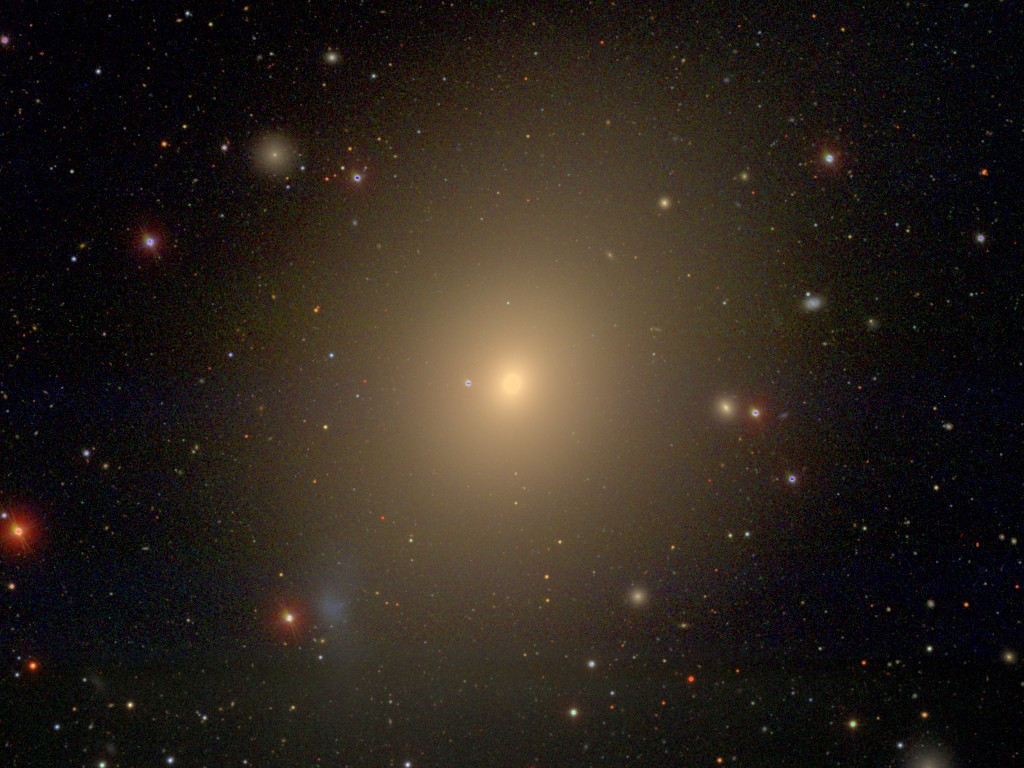

In [6]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/M49.jpeg"
Image(url)

_Credit: David W. Hogg, Michael R. Blanton, and the Sloan Digital Sky Survey Collaboration._

In [4]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/NGC4472_profile.csv"
ngc4472 = pd.read_csv(url)

The columns in the datasets are:
- **radius**: the radial distance $r$ on the sky from the core of the galaxy [arcsec]
- **surf_mag**: the surface brightness $\mu(r)$ of the galaxy  [mag/arcsec$^2$]

In the previous homework assignment, we tried to model the data using a parametric approach. We tested three different models of increasing sophistication. In all cases the residuals still contained systematic trends hinting at the inability of the models to accurately describe the underlying process.

In this homework task, we will test how well we can fit the data using a non-parametric (no fixed pre-supposed model function) approach: a Gaussian Process (GP).

Your tasks are the following:
    
1. Fit the data using a Gaussian process with a rational quadratic (RQ) covariance function.
2. List the best fit values of all the model parameters.
3. Visualize your results by plotting the mean of the GP as well as 20 randomly sampled functions from the GP, for $r^* =$ `linspace(3, 1000, 200)`, on top of the dataset.
4. What problem do you observe? Can you explain why it occurs?
5. Transform the dataset so that the observed problem is mitigated. Redo the modelling and the visualisation with the transformed dataset.

In [5]:
r = ngc4472['radius'].values
mu = ngc4472['surf_mag'].values

In [17]:
def build_GP(theta, x):
    amplitude = jnp.exp(theta["log_amplitude_sq"])
    scale     = jnp.exp(theta["log_scale"])
    alpha     = jnp.exp(theta["log_alpha"])
    kernel    = amplitude * kernels.RationalQuadratic(alpha=alpha, scale=scale)
    return GaussianProcess(kernel, x, diag=jnp.exp(theta["log_sigma_sq"]), mean=0.0)

@jax.jit
def neg_marginal_log_likelihood(theta, x, y):
    gp = build_GP(theta, x)
    return -gp.log_probability(y)

theta_init = {
    "log_amplitude_sq": np.log(1.0),
    "log_scale":        np.log(100.0),
    "log_alpha":        np.log(1.0),
    "log_sigma_sq":     np.log(0.1),
}

solver = jaxopt.ScipyMinimize(fun=neg_marginal_log_likelihood)
solution = solver.run(theta_init, x=r, y=mu)
print(f"Converged: {solution.state.success}")

Converged: False


In [18]:
print(f"amplitude: {np.sqrt(np.exp(solution.params['log_amplitude_sq'])):.4f}")
print(f"scale:     {np.exp(solution.params['log_scale']):.4f}")
print(f"alpha:     {np.exp(solution.params['log_alpha']):.4f}")
print(f"sigma:     {np.sqrt(np.exp(solution.params['log_sigma_sq'])):.4f}")

amplitude: 21.0414
scale:     36.5478
alpha:     41278.0409
sigma:     0.0076


The data was fitted using gaussian processes, with the best fit values seen above. However, the fit didn't properly converge. Looking at the plot, we can see that it diverges for larger radii, because it spans multiple orders of magnitude, which gives difficulty in the covariance matrix.

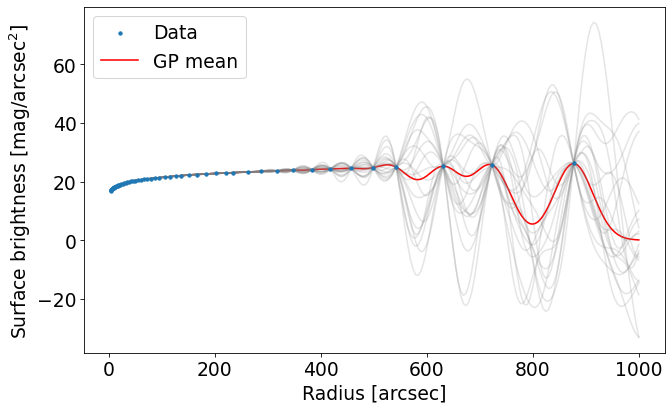

In [19]:
r_star = np.linspace(3, 1000, 200)

myGP = build_GP(solution.params, r)
conditionalGP = myGP.condition(mu, r_star).gp
mean = conditionalGP.loc

samples = conditionalGP.sample(jax.random.PRNGKey(42), shape=(20,))

plt.figure(figsize=(10, 6))
plt.scatter(r, mu, s=10, label='Data', zorder=5)
plt.plot(r_star, mean, color='red', label='GP mean')
for i in range(20):
    plt.plot(r_star, samples[i], color='gray', alpha=0.2)
plt.xlabel("Radius [arcsec]")
plt.ylabel(r"Surface brightness [mag/arcsec$^2$]")
plt.legend()
plt.show()

To mitigate the divergence, we change to a log scale, making the covariance matrix more uniform.

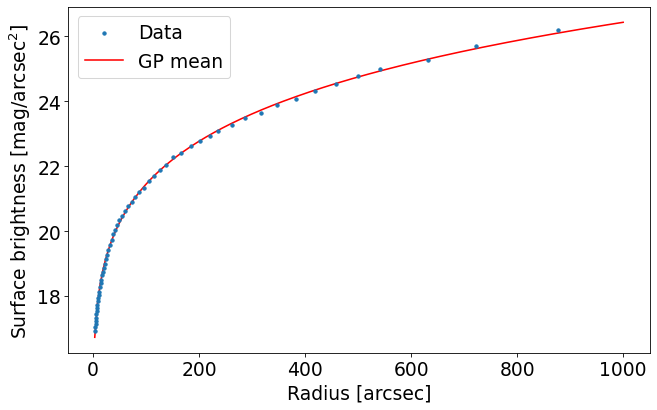

In [20]:
r_log = np.log10(r)
r_star_log = np.log10(np.linspace(3, 1000, 200))

# Refit with r_log instead of r
solution = solver.run(theta_init, x=r_log, y=mu)

myGP = build_GP(solution.params, r_log)
conditionalGP = myGP.condition(mu, r_star_log).gp
mean = conditionalGP.loc
samples = conditionalGP.sample(jax.random.PRNGKey(42), shape=(20,))

plt.figure(figsize=(10, 6))
plt.scatter(r, mu, s=10, label='Data', zorder=5)
plt.plot(np.linspace(3, 1000, 200), mean, color='red', label='GP mean')
for i in range(20):
    plt.plot(np.linspace(3, 1000, 200), samples[i], color='gray', alpha=0.2)
plt.xlabel("Radius [arcsec]")
plt.ylabel(r"Surface brightness [mag/arcsec$^2$]")
plt.legend()
plt.show()

We can see that the fit using gaussian processes and a log scale, does not have the problem of divergence and gives a good fit.

---